# N06 — Robustez de ventanas y regímenes (ML + DL)

Este notebook implementa **dos ejercicios de robustez** para el trabajo principal de pronóstico del USD/UYU:

1. **Ventana de entrenamiento**: comparar el baseline con **expanding window** (ya corrido en `N04` y `N05`) contra **rolling window** de **3 años** y **5 años**, manteniendo **fijos**:
   - el modelo elegido,
   - los hiperparámetros,
   - la definición del target,
   - las features / lags,
   - y la lógica de preprocesamiento.

2. **Estabilidad por régimen**: recalcular métricas OOS sobre:
   - muestra total,
   - tramo **pre 2020-09-04**,
   - tramo **post 2020-09-04**,

   usando como fecha de clasificación, por defecto, la **fecha de origen del forecast** (`fecha`).  
   El notebook también deja preparada una clasificación alternativa por `fecha_objetivo` para chequeos adicionales.

## Criterio metodológico

La comparación está diseñada para **aislar el efecto de la ventana**. Por eso:

- **no** se reabre la selección de modelos,
- **no** se retunean hiperparámetros,
- **no** se reoptimizan lags,

y **solo** se vuelve a correr el **walk-forward OOS** cambiando `window_type`.

## Insumos esperados en el proyecto

- `results_n02/df_st_daily_short_plazo.xlsx`
- `results_n02/df_st_daily_long_plazo.xlsx`
- `results_n00/df_daily.xlsx`
- `results_n04/...` con `fx_results_ml`, `fx_best_model_by_horizon`, `oos/`, `artifacts_ml/`
- `results_n05/...` con `fx_results_dl`, `fx_best_model_by_horizon_dl`, `oos/`, `artifacts_dl/`

## Salidas

Se guardan en:

- `results_n06_robustez/oos/`
- `results_n06_robustez/tables/`
- `results_n06_robustez/plots/`



In [12]:

# =========================
# 0) Imports + configuración
# =========================

import os
import re
import json
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False
    print("⚠️ lightgbm no disponible; si tu mejor ML es LGBM, instala la librería antes de correr.")

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("⚠️ xgboost no disponible; si tu mejor ML es XGBoost, instala la librería antes de correr.")

import joblib

# TensorFlow / Keras (solo necesario para la parte DL)
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks, optimizers
    HAS_TF = True
except Exception:
    HAS_TF = False
    print("⚠️ TensorFlow no disponible; la parte DL no correrá hasta instalarlo.")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
if HAS_TF:
    tf.random.set_seed(SEED)

DATE_COL = "Fecha"
TARGET_COL = "usd_dlog"
HORIZONS = {"1m": 21, "3m": 63, "6m": 126, "12m": 252}

# -------------------------
# Rutas base del proyecto
# -------------------------
BASE_DIR = Path.cwd()

RESULTS_N00 = BASE_DIR / "results_n00"
RESULTS_N02 = BASE_DIR / "results_n02"
RESULTS_N04 = BASE_DIR / "results_n04"
RESULTS_N05 = BASE_DIR / "results_n05"

SAVE_DIR = BASE_DIR / "results_n09"
OOS_OUT_DIR = SAVE_DIR / "oos"
TABLES_DIR = SAVE_DIR / "tables"
PLOTS_DIR = SAVE_DIR / "plots"
for d in [SAVE_DIR, OOS_OUT_DIR, TABLES_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Diseño del ejercicio
# -------------------------
TARGET_HORIZONS = ["1m", "12m"]   # el notebook queda listo para ampliar si luego quieres 3m/6m
AUTO_SELECT_BEST = True           # si True, toma los mejores modelos guardados en N04/N05
MANUAL_SELECTION = {
    # Sobrescribe AUTO_SELECT_BEST si pones None=False y completas a mano
    # "ML": {"1m": "LightGBM", "12m": "XGBoost"},
    # "DL": {"1m": "GRU", "12m": "CNN_GRU"},
}

WINDOW_CONFIGS = {
    "expanding": None,
    "rolling_3y": 756,   # ~3 años hábiles
    "rolling_5y": 1260,  # ~5 años hábiles
}

# Fecha de quiebre principal
REGIME_CUTOFF = pd.Timestamp("2020-09-04")

# Para DL, mantener control del costo computacional
DL_STEP_OOS = 5
DL_MIN_TRAIN_SEQ = 250
DL_EPOCHS_WF_MAX = 60
DL_PATIENCE_WF = 8
DL_VERBOSE_FIT = 0

# Correr o reutilizar rolling ya guardado
OVERWRITE_EXISTING_ROLLING = False

print("BASE_DIR:", BASE_DIR)
print("SAVE_DIR:", SAVE_DIR)
print("TARGET_HORIZONS:", TARGET_HORIZONS)
print("WINDOW_CONFIGS:", WINDOW_CONFIGS)
print("REGIME_CUTOFF:", REGIME_CUTOFF.date())


BASE_DIR: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA
SAVE_DIR: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n09
TARGET_HORIZONS: ['1m', '12m']
WINDOW_CONFIGS: {'expanding': None, 'rolling_3y': 756, 'rolling_5y': 1260}
REGIME_CUTOFF: 2020-09-04


## 1) Carga de datos base

Se reutilizan **los mismos datasets diarios** usados en `N04` y `N05`, además de la serie en **nivel** para reconstrucción del USD/UYU.


In [13]:

# =========================
# 1) Carga de datos base
# =========================

def assert_exists(path: Path, label: str = ""):
    if not path.exists():
        raise FileNotFoundError(f"No existe {label or path.name}: {path}")

assert_exists(RESULTS_N02 / "df_st_daily_short_plazo.xlsx", "df_st_daily_short_plazo.xlsx")
assert_exists(RESULTS_N02 / "df_st_daily_long_plazo.xlsx", "df_st_daily_long_plazo.xlsx")
assert_exists(RESULTS_N00 / "df_daily.xlsx", "df_daily.xlsx")

df_short = pd.read_excel(RESULTS_N02 / "df_st_daily_short_plazo.xlsx")
df_long  = pd.read_excel(RESULTS_N02 / "df_st_daily_long_plazo.xlsx")
df_level = pd.read_excel(RESULTS_N00 / "df_daily.xlsx")

for df in [df_short, df_long, df_level]:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df.dropna(subset=[DATE_COL], inplace=True)
    df.sort_values(DATE_COL, inplace=True)
    df.reset_index(drop=True, inplace=True)

if "dolar" not in df_level.columns:
    raise ValueError("df_daily.xlsx debe incluir la columna 'dolar'.")

def get_df_for_tag(tag: str) -> pd.DataFrame:
    return df_short.copy() if tag in ("1m", "3m") else df_long.copy()

print("df_short:", df_short.shape)
print("df_long :", df_long.shape)
print("df_level:", df_level.shape)

display(df_short.head(3))
display(df_long.head(3))
display(df_level[[DATE_COL, "dolar"]].head(3))


df_short: (2584, 52)
df_long : (2584, 52)
df_level: (2643, 125)


,Fecha,usd_dlog,EPU_br,dolar_mexico,exp_madera,exp_carne,derivados_financieros,IMESI,imp_EU,exp_brl,dolar_euro,imp_arg,exp_quimicos,exp_arg,exp_arroz,exp_veh_y_trans,dolar_canada,imp_patrimonio,ILF_lat,usd_br,tasa_pesos_familias,dolar_chile,tasa_dolares_familias,exp_EU,dolar_colombia,VIX,IRAE,imp_chn,pas_gob,dolar_india,int_deuda_gob,var_stock_pet,precio_soja,venta_autos,precio_carne,exp_inflacion,dolar_corea,precio_arroz,inversion_de_cartera,int_ANCAP,riesgo_BR,TCR_regional,dolar_peru,DXY_index,dolar_nueva_zelanda,NFCI,adq_neta_act_financieros,tasa_desempleo_usa,exp_agr_y_gan,WTI,emision,TPM_br
0,2015-04-01,-0.000778,317.27,15.01,17637,168829,13.08,2897.44,101741.7,102668.5,0.93,118725.8,39065,33631.3,13461,22638,1.26,1331.27,0.55,-0.05,39.36,-6.9,7.3,65208.9,-59.3,15.11,2583.6,213477.0,12962.44,-0.14,4290.42,2039.22,16.50,4955,0.48,0.6,-9.23,-9.5,-1065.9,32.41,-0.06,0.0,0.07,-0.17,0.00,0.0,-16.4,5.4,48915,2.40,1230.59,0.0
1,2015-04-06,-0.002727,317.27,14.92,17637,168829,13.08,2897.44,101741.7,102668.5,0.91,118725.8,39065,33631.3,13461,22638,1.25,1331.27,0.61,-0.07,39.36,-5.4,7.3,65208.9,-9.7,14.74,2583.6,213477.0,12962.44,-0.11,4290.42,2039.22,-11.25,4955,0.65,0.6,-8.75,4.5,-1065.9,32.41,-0.13,0.0,-0.01,-1.08,-0.01,0.0,-16.4,5.4,48915,1.96,284.39,0.0
2,2015-04-07,0.005059,317.27,14.91,17637,168829,13.08,2897.44,101741.7,102668.5,0.92,118725.8,39065,33631.3,13461,22638,1.25,1331.27,-0.08,0.03,39.36,-2.1,7.3,65208.9,-15.0,14.78,2583.6,213477.0,12962.44,0.25,4290.42,2039.22,-7.50,4955,0.55,0.6,3.20,-14.5,-1065.9,32.41,-0.03,0.0,0.02,0.72,0.00,0.0,-16.4,5.4,48915,1.87,-323.78,0.0


,Fecha,usd_dlog,tasa_dolares_familias,derivados_financieros,exp_arg,exp_carne,dolar_mexico,exp_quimicos,EPU_br,VIX,imp_arg,IMESI,exp_EU,dolar_euro,exp_madera,imp_EU,exp_brl,int_deuda_gob,exp_chn,pas_gob,IRAE,dolar_canada,var_stock_pet,exp_agr_y_gan,exp_veh_y_trans,inv_gob,tasa_pesos_familias,exp_inflacion,exp_arroz,inversion_de_cartera,usd_br,imp_chn,dolar_paraguay,dolar_chile,adq_neta_act_financieros,tasa_desempleo_usa,precio_soja,int_ANCAP,imp_eeuu,imp_patrimonio,venta_autos,precio_carne,precio_oro,TPM_br,act_ext_BCU,IPC_usa,IPC_br,dep_plazo_MN,SP500,FedFunds,IPC,tasa_pesos_empresas
0,2015-04-01,-0.000778,7.3,13.08,33631.3,168829,15.01,39065,317.27,15.11,118725.8,2897.44,65208.9,0.93,17637,101741.7,102668.5,4290.42,76288.6,12962.44,2583.6,1.26,2039.22,48915,22638,1557.15,39.36,0.6,13461,-1065.9,-0.05,213477.0,-2.7,-6.9,-16.4,5.4,16.50,32.41,60596.5,1331.27,4955,0.48,25.0,0.0,0.0,0.24,0.0,0.0,-8.20,0.01,0.0,0.0
1,2015-04-06,-0.002727,7.3,13.08,33631.3,168829,14.92,39065,317.27,14.74,118725.8,2897.44,65208.9,0.91,17637,101741.7,102668.5,4290.42,76288.6,12962.44,2583.6,1.25,2039.22,48915,22638,1557.15,39.36,0.6,13461,-1065.9,-0.07,213477.0,-22.5,-5.4,-16.4,5.4,-11.25,32.41,60596.5,1331.27,4955,0.65,10.5,0.0,0.0,0.00,0.0,0.0,20.93,0.00,0.0,0.0
2,2015-04-07,0.005059,7.3,13.08,33631.3,168829,14.91,39065,317.27,14.78,118725.8,2897.44,65208.9,0.92,17637,101741.7,102668.5,4290.42,76288.6,12962.44,2583.6,1.25,2039.22,48915,22638,1557.15,39.36,0.6,13461,-1065.9,0.03,213477.0,108.9,-2.1,-16.4,5.4,-7.50,32.41,60596.5,1331.27,4955,0.55,-8.0,0.0,0.0,0.00,0.0,0.0,-4.29,0.00,0.0,0.0


,Fecha,dolar
0,2015-01-05,24.15
1,2015-01-07,24.23
2,2015-01-08,24.36


## 2) Helpers comunes

Se copian/adaptan funciones clave de `N04` y `N05` para garantizar que el armado del target, las features y la reconstrucción en nivel sean **idénticos** al pipeline original.


In [14]:

# =========================
# 2) Helpers comunes
# =========================

def future_sum(series: pd.Series, H: int) -> pd.Series:
    """r_H(t) = sum_{j=1..H} r_{t+j}, alineado en t."""
    base = series.astype(float)
    return base.shift(-1).rolling(H).sum().shift(-(H - 1))

def infer_monthly_features(df: pd.DataFrame, feature_cols, threshold_median_nunique: float = 1.0):
    """Heurística original de N04 para detectar variables 'mensuales' en un dataset diario."""
    if len(feature_cols) == 0:
        return set()

    m = pd.to_datetime(df[DATE_COL]).dt.to_period("M")
    monthly = set()
    for c in feature_cols:
        try:
            nun = df.groupby(m)[c].nunique(dropna=True)
            if float(nun.median()) <= float(threshold_median_nunique):
                monthly.add(c)
        except Exception:
            pass
    return monthly

import re
import pandas as pd

def build_X_from_feature_list(
    df: pd.DataFrame,
    feature_list: list[str]
) -> pd.DataFrame:
    """
    Reconstruye exactamente las columnas requeridas por el artefacto
    usando la lista de features guardada en features.json.

    Soporta features con patrón:
      - {col}_L{k}   -> lag k de la columna base
      - {col}        -> columna contemporánea/directa

    Devuelve X con:
      - mismo nombre de columnas que feature_list
      - mismo orden que feature_list
    """
    df = df.copy()
    X_parts = []

    lag_pattern = re.compile(r"^(.+)_L(\d+)$")

    for feat in feature_list:
        m = lag_pattern.match(feat)

        if m:
            base_col = m.group(1)
            lag = int(m.group(2))

            if base_col not in df.columns:
                raise KeyError(
                    f"No se encontró la columna base '{base_col}' "
                    f"para reconstruir la feature '{feat}'."
                )

            X_parts.append(df[base_col].shift(lag).rename(feat))

        else:
            if feat not in df.columns:
                raise KeyError(
                    f"La feature directa '{feat}' no existe en el DataFrame."
                )

            X_parts.append(df[feat].rename(feat))

    X = pd.concat(X_parts, axis=1)

    # Reorden explícito para garantizar mismo orden que el artefacto
    X = X[feature_list].copy()

    return X

def build_xy_exact_from_artifact_features(
    df: pd.DataFrame,
    target_col: str,
    H: int,
    feature_list: list[str],
    date_col: str = DATE_COL
):
    """
    Construye X, y y fechas replicando EXACTAMENTE las features
    guardadas en el artefacto del mejor modelo.

    - X se reconstruye desde feature_list
    - y = future_sum(target_col, H)
    - se alinean X, y y fechas con dropna()

    Devuelve:
    X, y, dates
    """
    df = df.copy()

    if date_col not in df.columns:
        raise KeyError(f"La columna de fecha '{date_col}' no existe en df.")

    if target_col not in df.columns:
        raise KeyError(f"La columna target '{target_col}' no existe en df.")

    y = future_sum(df[target_col], H).rename(f"r_{H}")
    X = build_X_from_feature_list(df, feature_list)

    out = pd.concat([df[[date_col]], X, y], axis=1).dropna().reset_index(drop=True)

    dates = pd.to_datetime(out[date_col]).reset_index(drop=True)
    X = out[feature_list].copy().reset_index(drop=True)
    y = out[y.name].astype(float).reset_index(drop=True)

    return X, y, dates


def build_sequences(df: pd.DataFrame, H: int, lookback: int = 30, include_target_history: bool = True):
    """Armado de secuencias con la misma lógica de N05."""
    if TARGET_COL not in df.columns:
        raise ValueError(f"No existe target {TARGET_COL} en dataset.")

    y = future_sum(df[TARGET_COL], H)

    if include_target_history:
        feat_cols = [c for c in df.columns if c != DATE_COL]
    else:
        feat_cols = [c for c in df.columns if c not in [DATE_COL, TARGET_COL]]

    X_raw = df[feat_cols].astype(float)

    X_list, y_list, dt_list = [], [], []
    for t in range(lookback - 1, len(df)):
        if pd.isna(y.iloc[t]):
            continue
        window = X_raw.iloc[t - lookback + 1 : t + 1]
        if window.isna().any().any():
            continue
        X_list.append(window.values)
        y_list.append(float(y.iloc[t]))
        dt_list.append(df[DATE_COL].iloc[t])

    X = np.array(X_list, dtype=float)
    y = np.array(y_list, dtype=float)
    dts = pd.to_datetime(pd.Series(dt_list)).reset_index(drop=True)
    return X, y, dts, feat_cols

def reconstruct_level_from_oos(oos_df: pd.DataFrame, H: int) -> pd.DataFrame:
    """Reconstruye USD/UYU en nivel a partir de y_pred y y_true acumulados."""
    tmp = oos_df.copy()
    tmp["fecha"] = pd.to_datetime(tmp["fecha"], errors="coerce")

    mapH = df_level.copy()
    mapH["fecha_objetivo"] = mapH[DATE_COL].shift(-H)
    mapH["dolar_real_tH"] = mapH["dolar"].shift(-H)
    mapH = mapH.rename(columns={DATE_COL: "fecha", "dolar": "dolar_t"})
    mapH = mapH[["fecha", "dolar_t", "fecha_objetivo", "dolar_real_tH"]]

    out = tmp.merge(mapH, on="fecha", how="left")
    out["dolar_pred_tH"] = out["dolar_t"] * np.exp(out["y_pred"])
    out["dolar_true_tH"] = out["dolar_t"] * np.exp(out["y_true"])

    out = out.dropna(subset=["fecha_objetivo", "dolar_t", "dolar_real_tH", "dolar_pred_tH"]).reset_index(drop=True)
    return out

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def compute_level_metrics(df_eval: pd.DataFrame) -> dict:
    y_true = df_eval["dolar_real_tH"].astype(float)
    y_pred = df_eval["dolar_pred_tH"].astype(float)
    return {
        "n": int(len(df_eval)),
        "MAE_level": float(mean_absolute_error(y_true, y_pred)),
        "RMSE_level": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2_level": float(r2_score(y_true, y_pred)) if len(df_eval) >= 2 else np.nan
    }

def standardize_oos_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Homogeneiza outputs de N04 (mayúsculas) y N05 (minúsculas)."""
    out = df.copy()
    rename_map = {}
    if "Fecha" in out.columns:
        rename_map["Fecha"] = "fecha"
    if "Fecha_objetivo" in out.columns:
        rename_map["Fecha_objetivo"] = "fecha_objetivo"
    out = out.rename(columns=rename_map)

    # si existen retornos guardados, los mantenemos
    keep = [c for c in out.columns if c in [
        "fecha", "fecha_objetivo", "dolar_t", "dolar_pred_tH", "dolar_real_tH",
        "y_true", "y_pred", "dolar_true_tH"
    ]]
    out = out[keep].copy()

    if "fecha" in out.columns:
        out["fecha"] = pd.to_datetime(out["fecha"], errors="coerce")
    if "fecha_objetivo" in out.columns:
        out["fecha_objetivo"] = pd.to_datetime(out["fecha_objetivo"], errors="coerce")
    return out

def ml_safe_name(model_name: str) -> str:
    return str(model_name).replace("(", "").replace(")", "").replace(" ", "")

def dl_safe_name(model_name: str) -> str:
    return re.sub(r"[^A-Za-z0-9_]+", "", str(model_name).replace(" ", "_"))


## 3) Lectura de resultados baseline y selección de experimentos

Por defecto se toman los **mejores modelos por horizonte** ya guardados por los notebooks principales:

- `results_n04/fx_best_model_by_horizon.csv`
- `results_n05/fx_best_model_by_horizon_dl.csv`

Si prefieres una selección manual, puedes desactivar `AUTO_SELECT_BEST` y completar `MANUAL_SELECTION`.


In [15]:

# =========================
# 3) Selección de experimentos
# =========================

def read_best_file(path_csv: Path, path_xlsx: Path) -> pd.DataFrame:
    if path_csv.exists():
        return pd.read_csv(path_csv)
    if path_xlsx.exists():
        return pd.read_excel(path_xlsx)
    raise FileNotFoundError(f"No encontré ni {path_csv.name} ni {path_xlsx.name}")

best_ml = read_best_file(
    RESULTS_N04 / "fx_best_model_by_horizon.csv",
    RESULTS_N04 / "fx_best_model_by_horizon.xlsx",
)
best_dl = read_best_file(
    RESULTS_N05 / "fx_best_model_by_horizon_dl.csv",
    RESULTS_N05 / "fx_best_model_by_horizon_dl.xlsx",
)

display(best_ml)
display(best_dl)

def build_experiment_selection():
    rows = []

    if AUTO_SELECT_BEST:
        for h in TARGET_HORIZONS:
            r_ml = best_ml.loc[best_ml["h_tag"] == h]
            if len(r_ml) == 0:
                raise ValueError(f"No encuentro mejor ML para horizonte {h}.")
            rows.append({
                "family": "ML",
                "h_tag": h,
                "model": str(r_ml.iloc[0]["model"])
            })

            r_dl = best_dl.loc[best_dl["h_tag"] == h]
            if len(r_dl) == 0:
                raise ValueError(f"No encuentro mejor DL para horizonte {h}.")
            rows.append({
                "family": "DL",
                "h_tag": h,
                "model": str(r_dl.iloc[0]["model"])
            })
    else:
        for fam in ["ML", "DL"]:
            if fam not in MANUAL_SELECTION:
                raise ValueError(f"Falta MANUAL_SELECTION['{fam}'].")
            for h in TARGET_HORIZONS:
                if h not in MANUAL_SELECTION[fam]:
                    raise ValueError(f"Falta selección manual para {fam} - {h}.")
                rows.append({"family": fam, "h_tag": h, "model": MANUAL_SELECTION[fam][h]})

    exp = pd.DataFrame(rows).sort_values(["family", "h_tag"]).reset_index(drop=True)
    return exp

experiments = build_experiment_selection()
# Quedarnos solo con ML
experiments = (
    experiments
    .loc[experiments["family"] == "ML"]
    .reset_index(drop=True)
)

display(experiments)

experiments.to_csv(TABLES_DIR / "selected_experiments.csv", index=False)
print("✅ Selección guardada en:", TABLES_DIR / "selected_experiments.csv")


,h_tag,H_days,model,MAE_level,RMSE_level,R2_level,params,best_cv_score,lag_cfg,daily_lags,monthly_lags,target_lags,search_min,oos_min,n_oos
0,1m,21,RandomForest,0.364530,0.469680,0.920854,"{'n_estimators': 500, 'min_samples_split': 2, ...",-0.019241,d1_10_m6_t1_10,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[21, 42, 63, 84, 105, 126]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",0.339065,6.880638,732
1,3m,63,LightGBM,0.376786,0.489653,0.914790,"{'subsample': 0.85, 'reg_lambda': 0.0, 'reg_al...",-0.034731,d1_10_m6_t1_10,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[21, 42, 63, 84, 105, 126]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",1.060425,15.864448,719
2,6m,126,LightGBM,0.475298,0.643978,0.855705,"{'subsample': 0.85, 'reg_lambda': 0.0, 'reg_al...",-0.043387,d1_30_m6_t1_20,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[21, 42, 63, 84, 105, 126]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1.439310,25.023215,700
3,12m,252,RandomForest,0.433686,0.550427,0.898775,"{'n_estimators': 300, 'min_samples_split': 2, ...",-0.069308,d1_10_m6_t1_10,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[21, 42, 63, 84, 105, 126]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",0.331366,5.041442,662


,h_tag,H_days,family,model,model_safe,MAE,RMSE,R2,MAE_level,RMSE_level,R2_level,params,params_json,search_min,oos_min,n_total_seq,n_initial_train,n_initial_val,oos_points,step_oos,n_level
0,12m,252,DL,CNN_GRU,CNN_GRU,0.061013,0.076874,-2.349586,2.450054,3.086885,-2.704792,"{""units"": 64, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 64, ""dropout"": 0.3, ""lr"": 0.002}",3.810587,27.039238,2303,1612,345,70,5,70
1,1m,21,DL,LSTM,LSTM,0.021700,0.028835,-1.039289,0.890332,1.184915,0.525662,"{""units"": 96, ""dropout"": 0.1, ""lr"": 0.002}","{""units"": 96, ""dropout"": 0.1, ""lr"": 0.002}",3.456362,19.443885,2534,1773,380,77,5,77
2,3m,63,DL,ATTN_LSTM,ATTN_LSTM,0.034645,0.044477,-0.182323,1.415755,1.823736,-0.148973,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.002}",4.629359,38.085363,2492,1744,374,75,5,75
3,6m,126,DL,CNN_LSTM,CNN_LSTM,0.050204,0.062053,-0.046876,2.072003,2.575171,-1.319190,"{""units"": 128, ""dropout"": 0.3, ""lr"": 0.001}","{""units"": 128, ""dropout"": 0.3, ""lr"": 0.001}",3.868998,24.190563,2429,1700,364,73,5,73


,family,h_tag,model
0,ML,12m,RandomForest
1,ML,1m,RandomForest


✅ Selección guardada en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n09\tables\selected_experiments.csv


## 4) Carga de artefactos y metadatos del baseline

Aquí se recuperan, para cada experimento seleccionado:

- OOS baseline (`expanding`) ya guardado,
- `params.json`,
- `metadata.json`,
- `features.json`.

Esto permite **replicar exactamente** la especificación del modelo principal y reejecutar solo el `walk-forward` con rolling.


In [16]:

# =========================
# 4) Carga de baseline y artefactos
# =========================

def locate_ml_artifact_dir(h_tag: str, model_name: str) -> Path:
    candidates = [
        RESULTS_N04 / "artifacts_ml" / h_tag / ml_safe_name(model_name),
        BASE_DIR / "artifacts_ml" / h_tag / ml_safe_name(model_name),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No encontré artifacts ML para {model_name} @ {h_tag}")

def locate_dl_artifact_dir(h_tag: str, model_name: str) -> Path:
    candidates = [
        RESULTS_N05 / "artifacts_dl" / h_tag / dl_safe_name(model_name),
        BASE_DIR / "artifacts_dl" / h_tag / dl_safe_name(model_name),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No encontré artifacts DL para {model_name} @ {h_tag}")

def locate_baseline_oos(family: str, h_tag: str, model_name: str) -> Path:
    if family == "ML":
        safe = ml_safe_name(model_name)
        candidates = [
            RESULTS_N04 / "oos" / f"oos_{h_tag}_{safe}.csv",
            RESULTS_N04 / "oos" / f"oos_{h_tag}_{safe}.xlsx",
        ]
    else:
        safe = dl_safe_name(model_name)
        candidates = [
            RESULTS_N05 / "oos" / f"oos_{h_tag}_{safe}.csv",
            RESULTS_N05 / "oos" / f"oos_{h_tag}_{safe}.xlsx",
        ]

    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No encontré OOS baseline para {family} | {model_name} | {h_tag}")

def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def read_oos_file(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)
    return standardize_oos_columns(df)

def load_experiment_bundle(row: pd.Series) -> dict:
    family = row["family"]
    h_tag = row["h_tag"]
    model_name = row["model"]

    if family == "ML":
        art_dir = locate_ml_artifact_dir(h_tag, model_name)
    else:
        art_dir = locate_dl_artifact_dir(h_tag, model_name)

    params = read_json(art_dir / "params.json")
    metadata = read_json(art_dir / "metadata.json")
    features = read_json(art_dir / "features.json")
    oos_path = locate_baseline_oos(family, h_tag, model_name)
    baseline_oos = read_oos_file(oos_path)

    bundle = {
        "family": family,
        "h_tag": h_tag,
        "H_days": int(HORIZONS[h_tag]),
        "model": model_name,
        "artifact_dir": art_dir,
        "params": params,
        "metadata": metadata,
        "features": features,
        "baseline_oos": baseline_oos,
        "baseline_oos_path": oos_path,
    }
    return bundle

bundles = [load_experiment_bundle(r) for _, r in experiments.iterrows()]

summary_rows = []
for b in bundles:
    summary_rows.append({
        "family": b["family"],
        "h_tag": b["h_tag"],
        "model": b["model"],
        "artifact_dir": str(b["artifact_dir"]),
        "baseline_oos_rows": len(b["baseline_oos"]),
        "baseline_oos_min": b["baseline_oos"]["fecha"].min(),
        "baseline_oos_max": b["baseline_oos"]["fecha"].max(),
    })

bundles_df = pd.DataFrame(summary_rows)
display(bundles_df)
bundles_df.to_csv(TABLES_DIR / "bundles_loaded.csv", index=False)


,family,h_tag,model,artifact_dir,baseline_oos_rows,baseline_oos_min,baseline_oos_max
0,ML,12m,RandomForest,c:\Users\jbrio\OneDrive - Universidad de Monte...,662,2022-01-03,2024-09-02
1,ML,1m,RandomForest,c:\Users\jbrio\OneDrive - Universidad de Monte...,732,2022-08-29,2025-08-06


## 5) Runners de rolling — ML

El runner de ML:

- reconstruye `X`, `y` y `dates` con la **misma lógica** de `N04`,
- recupera el `lag_cfg` y los `best_params` guardados,
- instancia **el mismo modelo** con **los mismos hiperparámetros**,
- y vuelve a correr el `walk-forward` cambiando solo la ventana de entrenamiento.


In [17]:

# =========================
# 5) ML - instanciación + rolling runner
# =========================

def instantiate_ml_model(model_label: str, best_params: dict):
    model_label = str(model_label)

    if model_label == "RandomForest":
        params = dict(best_params)
        params.setdefault("random_state", SEED)
        params.setdefault("n_jobs", -1)
        return RandomForestRegressor(**params)

    if model_label == "XGBoost":
        if not HAS_XGB:
            raise ImportError("XGBoost no disponible en el entorno.")
        params = dict(best_params)
        params.setdefault("objective", "reg:squarederror")
        params.setdefault("n_estimators", 800)
        params.setdefault("random_state", SEED)
        params.setdefault("tree_method", "hist")
        params.setdefault("n_jobs", -1)
        return XGBRegressor(**params)

    if model_label == "LightGBM":
        if not HAS_LGBM:
            raise ImportError("LightGBM no disponible en el entorno.")
        params = dict(best_params)
        params.setdefault("boosting_type", "gbdt")
        params.setdefault("objective", "regression")
        params.setdefault("n_estimators", 800)
        params.setdefault("random_state", SEED)
        params.setdefault("n_jobs", -1)
        return lgb.LGBMRegressor(**params)

    if model_label == "SVR_RBF":
        params = dict(best_params)
        return Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf", **params))
        ])

    raise ValueError(f"Modelo ML no soportado en notebook de robustez: {model_label}")

def run_ml_window(bundle: dict, window_name: str, rolling_size: int | None):
    if bundle["family"] != "ML":
        raise ValueError("run_ml_window solo acepta bundles ML.")

    h_tag = bundle["h_tag"]
    H = bundle["H_days"]
    model_name = bundle["model"]
    params = bundle["params"]
    metadata = bundle["metadata"]

    lag_cfg = params.get("lag_cfg", None)
    if lag_cfg is None:
        raise ValueError(f"No encontré lag_cfg en params.json para {model_name}@{h_tag}")

    best_params = params.get("best_params", {})
    initial_train_size = int(metadata.get("initial_train_size", 0))
    step_oos = int(metadata.get("step_oos", 1))
    if initial_train_size <= 0:
        raise ValueError(f"initial_train_size inválido para {model_name}@{h_tag}: {initial_train_size}")

    df = get_df_for_tag(h_tag)
    expected_features = list(bundle["features"])
    X, y, dates = build_xy_exact_from_artifact_features(
        df=df,
        target_col=TARGET_COL,
        H=H,
        feature_list=expected_features,
        date_col=DATE_COL
    )

    # Reordenar y recortar EXACTAMENTE al set de columnas guardado
    expected_features = list(bundle["features"])
    missing = [c for c in expected_features if c not in X.columns]
    extra = [c for c in X.columns if c not in expected_features]
    if missing:
        raise ValueError(
            f"Faltan columnas esperadas para {model_name}@{h_tag}: {missing[:10]} "
            f"(total faltantes={len(missing)})"
        )
    if extra:
        # No es error; simplemente restringimos a las columnas efectivamente guardadas.
        pass
    X = X[expected_features].copy()

    start_idx = initial_train_size if rolling_size is None else max(initial_train_size, rolling_size)

    rows = []
    total_steps = len(range(start_idx, len(y), step_oos))
    t0 = time.perf_counter()

    for j, end in enumerate(range(start_idx, len(y), step_oos), 1):
        if rolling_size is None:
            start_train = 0
        else:
            start_train = max(0, end - rolling_size)

        est = instantiate_ml_model(model_name, best_params)
        est.fit(X.iloc[start_train:end], y.iloc[start_train:end])
        y_hat = float(est.predict(X.iloc[[end]])[0])

        rows.append({
            "fecha": pd.to_datetime(dates.iloc[end]),
            "y_true": float(y.iloc[end]),
            "y_pred": y_hat
        })

        if (j % 50 == 0) or (j == total_steps):
            elapsed = (time.perf_counter() - t0) / 60.0
            print(f"[ML|{model_name}|{h_tag}|{window_name}] {j}/{total_steps} iter | elapsed={elapsed:.2f} min")

    oos = pd.DataFrame(rows)
    out = reconstruct_level_from_oos(oos, H)
    out["family"] = "ML"
    out["model"] = model_name
    out["h_tag"] = h_tag
    out["window_type"] = window_name
    out["rolling_size"] = rolling_size
    return out


## 6) Runners de rolling — DL

En DL se reconstruye la arquitectura original de `N05`, se cargan los hiperparámetros ganadores guardados y se reejecuta el `walk-forward` con:

- mismos `units`, `dropout`, `lr`,
- mismo `lookback`,
- mismo `STEP_OOS_DL`,
- mismo `split` interno train/val en cada iteración,

cambiando solamente la ventana (`expanding` vs `rolling`).


In [ ]:

# =========================
# 6) DL - builders + rolling runner
# =========================

if HAS_TF:
    class SimpleAttention(layers.Layer):
        def __init__(self, **kwargs):
            super().__init__(**kwargs)

        def build(self, input_shape):
            self.W = self.add_weight(
                shape=(input_shape[-1], 1),
                initializer="glorot_uniform",
                trainable=True,
                name="att_weight"
            )
            self.b = self.add_weight(
                shape=(input_shape[1], 1),
                initializer="zeros",
                trainable=True,
                name="att_bias"
            )
            super().build(input_shape)

        def call(self, x):
            e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
            a = tf.nn.softmax(e, axis=1)
            return tf.reduce_sum(x * a, axis=1)

    def build_lstm_model(input_shape, units, dropout, lr):
        model = models.Sequential([
            layers.Input(shape=input_shape),
            layers.LSTM(units),
            layers.Dropout(dropout),
            layers.Dense(1)
        ])
        model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def build_gru_model(input_shape, units, dropout, lr):
        model = models.Sequential([
            layers.Input(shape=input_shape),
            layers.GRU(units),
            layers.Dropout(dropout),
            layers.Dense(1)
        ])
        model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def build_cnn_lstm_model(input_shape, units, dropout, lr):
        model = models.Sequential([
            layers.Input(shape=input_shape),
            layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
            layers.MaxPooling1D(pool_size=2),
            layers.LSTM(units),
            layers.Dropout(dropout),
            layers.Dense(1)
        ])
        model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def build_cnn_gru_model(input_shape, units, dropout, lr):
        model = models.Sequential([
            layers.Input(shape=input_shape),
            layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
            layers.MaxPooling1D(pool_size=2),
            layers.GRU(units),
            layers.Dropout(dropout),
            layers.Dense(1)
        ])
        model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def build_attn_lstm_model(input_shape, units, dropout, lr):
        inp = layers.Input(shape=input_shape)
        x = layers.LSTM(units, return_sequences=True)(inp)
        x = layers.Dropout(dropout)(x)
        x = SimpleAttention()(x)
        out = layers.Dense(1)(x)
        model = models.Model(inp, out)
        model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def build_attn_gru_model(input_shape, units, dropout, lr):
        inp = layers.Input(shape=input_shape)
        x = layers.GRU(units, return_sequences=True)(inp)
        x = layers.Dropout(dropout)(x)
        x = SimpleAttention()(x)
        out = layers.Dense(1)(x)
        model = models.Model(inp, out)
        model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def build_cnn_attn_lstm_model(input_shape, units, dropout, lr):
        inp = layers.Input(shape=input_shape)
        x = layers.Conv1D(filters=32, kernel_size=3, activation="relu")(inp)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.LSTM(units, return_sequences=True)(x)
        x = layers.Dropout(dropout)(x)
        x = SimpleAttention()(x)
        out = layers.Dense(1)(x)
        model = models.Model(inp, out)
        model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    def build_cnn_attn_gru_model(input_shape, units, dropout, lr):
        inp = layers.Input(shape=input_shape)
        x = layers.Conv1D(filters=32, kernel_size=3, activation="relu")(inp)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.GRU(units, return_sequences=True)(x)
        x = layers.Dropout(dropout)(x)
        x = SimpleAttention()(x)
        out = layers.Dense(1)(x)
        model = models.Model(inp, out)
        model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
        return model

    DL_BUILDERS = {
        "LSTM": build_lstm_model,
        "GRU": build_gru_model,
        "CNN_LSTM": build_cnn_lstm_model,
        "CNN_GRU": build_cnn_gru_model,
        "Attn_LSTM": build_attn_lstm_model,
        "Attn_GRU": build_attn_gru_model,
        "CNN_Attn_LSTM": build_cnn_attn_lstm_model,
        "CNN_Attn_GRU": build_cnn_attn_gru_model,
    }

def run_dl_window(bundle: dict, window_name: str, rolling_size: int | None):
    if bundle["family"] != "DL":
        raise ValueError("run_dl_window solo acepta bundles DL.")
    if not HAS_TF:
        raise ImportError("TensorFlow no está disponible en el entorno.")

    h_tag = bundle["h_tag"]
    H = bundle["H_days"]
    model_name = bundle["model"]
    params = bundle["params"]
    metadata = bundle["metadata"]

    if model_name not in DL_BUILDERS:
        raise ValueError(f"Builder DL no soportado en notebook de robustez: {model_name}")

    builder = DL_BUILDERS[model_name]
    lookback = int(metadata.get("lookback", 30))
    include_target_history = True  # en N05 estaba activo por defecto

    df = get_df_for_tag(h_tag)
    X, y, dts, feat_cols = build_sequences(
        df=df,
        H=H,
        lookback=lookback,
        include_target_history=include_target_history
    )

    n = len(y)
    n_initial_train = int(metadata.get("n_initial_train", 0))
    n_initial_val = int(metadata.get("n_initial_val", 0))
    i2 = n_initial_train + n_initial_val
    if i2 <= 0:
        raise ValueError(f"No pude reconstruir el inicio OOS para {model_name}@{h_tag}")

    start_idx = i2 if rolling_size is None else max(i2, rolling_size)
    total_steps = len(range(start_idx, n, DL_STEP_OOS))
    if total_steps == 0:
        raise ValueError(f"No hay pasos OOS para {model_name}@{h_tag} con window={window_name}")

    units = int(params["units"])
    dropout = float(params["dropout"])
    lr = float(params["lr"])
    val_frac = float(metadata.get("val_frac", 0.15))

    def scale3d_with(scaler, A, fit=False):
        n_feat = A.shape[-1]
        A2 = A.reshape(-1, n_feat)
        A2 = scaler.fit_transform(A2) if fit else scaler.transform(A2)
        return A2.reshape(A.shape)

    def fit_one_iteration(X_hist, y_hist):
        m = len(y_hist)
        val_size = max(30, int(m * val_frac))
        val_size = min(val_size, max(1, m - 1))
        tr_end = m - val_size

        X_tr, y_tr = X_hist[:tr_end], y_hist[:tr_end]
        X_va, y_va = X_hist[tr_end:], y_hist[tr_end:]

        scaler = StandardScaler()
        X_tr_s = scale3d_with(scaler, X_tr, fit=True)
        X_va_s = scale3d_with(scaler, X_va, fit=False)

        model = builder(X_tr_s.shape[1:], units, dropout, lr)
        es = callbacks.EarlyStopping(
            monitor="val_loss",
            patience=DL_PATIENCE_WF,
            restore_best_weights=True
        )
        model.fit(
            X_tr_s, y_tr,
            validation_data=(X_va_s, y_va),
            epochs=DL_EPOCHS_WF_MAX,
            batch_size=32,
            verbose=DL_VERBOSE_FIT,
            callbacks=[es]
        )
        return model, scaler

    rows = []
    t0 = time.perf_counter()

    for j, i in enumerate(range(start_idx, n, DL_STEP_OOS), 1):
        if rolling_size is None:
            start_train = 0
        else:
            start_train = max(0, i - rolling_size)

        X_hist = X[start_train:i]
        y_hist = y[start_train:i]

        if len(y_hist) < DL_MIN_TRAIN_SEQ:
            continue

        model_i, scaler_i = fit_one_iteration(X_hist, y_hist)

        X_i = X[i:i+1]
        X_i_s = scale3d_with(scaler_i, X_i, fit=False)
        pred = float(model_i.predict(X_i_s, verbose=0).reshape(-1)[0])

        rows.append({
            "fecha": pd.to_datetime(dts.iloc[i]),
            "y_true": float(y[i]),
            "y_pred": pred
        })

        try:
            tf.keras.backend.clear_session()
        except Exception:
            pass

        if (j % 20 == 0) or (j == total_steps):
            elapsed = (time.perf_counter() - t0) / 60.0
            print(f"[DL|{model_name}|{h_tag}|{window_name}] {j}/{total_steps} iter | elapsed={elapsed:.2f} min")

    oos = pd.DataFrame(rows)
    if len(oos) == 0:
        raise RuntimeError(f"No se generaron predicciones OOS para {model_name}@{h_tag}|{window_name}")

    out = reconstruct_level_from_oos(oos, H)
    out["family"] = "DL"
    out["model"] = model_name
    out["h_tag"] = h_tag
    out["window_type"] = window_name
    out["rolling_size"] = rolling_size
    return out


## 7) Ejecución del ejercicio de robustez de ventanas

- `expanding`: se lee del OOS ya guardado.
- `rolling_3y` y `rolling_5y`: se recalculan aquí con la **misma especificación** del baseline.

Cada output se guarda inmediatamente para no perder trazabilidad.


In [18]:

# =========================
# 7) Ejecutar / reutilizar OOS de robustez
# =========================

def robust_oos_output_path(bundle: dict, window_name: str) -> Path:
    safe = ml_safe_name(bundle["model"]) if bundle["family"] == "ML" else dl_safe_name(bundle["model"])
    return OOS_OUT_DIR / f"oos_{bundle['family'].lower()}_{bundle['h_tag']}_{safe}_{window_name}.csv"

def save_robust_oos(df_oos: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df_oos.to_csv(path, index=False)

all_oos = []

for bundle in bundles:
    family = bundle["family"]
    h_tag = bundle["h_tag"]
    model_name = bundle["model"]
    print("\n" + "="*90)
    print(f"Experimento: {family} | {model_name} | {h_tag}")
    print("="*90)

    # 1) Expanding baseline (ya hecho)
    base = bundle["baseline_oos"].copy()
    base["family"] = family
    base["model"] = model_name
    base["h_tag"] = h_tag
    base["window_type"] = "expanding"
    base["rolling_size"] = np.nan

    # Si baseline no trae y_true/y_pred (caso DL), no es problema: la comparación principal será en nivel
    all_oos.append(base)

    # 2) Rolling windows
    for window_name, rolling_size in WINDOW_CONFIGS.items():
        if window_name == "expanding":
            continue

        out_path = robust_oos_output_path(bundle, window_name)

        if out_path.exists() and not OVERWRITE_EXISTING_ROLLING:
            print(f"↪ Reutilizando archivo ya guardado: {out_path.name}")
            df_roll = pd.read_csv(out_path)
            df_roll = standardize_oos_columns(df_roll)
            if "family" not in df_roll.columns:
                df_roll["family"] = family
            if "model" not in df_roll.columns:
                df_roll["model"] = model_name
            if "h_tag" not in df_roll.columns:
                df_roll["h_tag"] = h_tag
            if "window_type" not in df_roll.columns:
                df_roll["window_type"] = window_name
            if "rolling_size" not in df_roll.columns:
                df_roll["rolling_size"] = rolling_size
        else:
            print(f"▶ Corriendo {window_name} para {family} | {model_name} | {h_tag}")
            if family == "ML":
                df_roll = run_ml_window(bundle, window_name, rolling_size)
            else:
                df_roll = run_dl_window(bundle, window_name, rolling_size)
            save_robust_oos(df_roll, out_path)
            print(f"✅ Guardado: {out_path}")

        all_oos.append(df_roll)

oos_all = pd.concat(all_oos, ignore_index=True)
oos_all["fecha"] = pd.to_datetime(oos_all["fecha"], errors="coerce")
oos_all["fecha_objetivo"] = pd.to_datetime(oos_all["fecha_objetivo"], errors="coerce")

print("Shape consolidado OOS:", oos_all.shape)
display(oos_all.head())

oos_all.to_csv(TABLES_DIR / "oos_all_windows_raw.csv", index=False)
print("✅ OOS consolidado (raw) guardado en:", TABLES_DIR / "oos_all_windows_raw.csv")



Experimento: ML | RandomForest | 12m
▶ Corriendo rolling_3y para ML | RandomForest | 12m
[ML|RandomForest|12m|rolling_3y] 50/662 iter | elapsed=0.51 min
[ML|RandomForest|12m|rolling_3y] 100/662 iter | elapsed=1.01 min
[ML|RandomForest|12m|rolling_3y] 150/662 iter | elapsed=1.50 min
[ML|RandomForest|12m|rolling_3y] 200/662 iter | elapsed=1.97 min
[ML|RandomForest|12m|rolling_3y] 250/662 iter | elapsed=2.45 min
[ML|RandomForest|12m|rolling_3y] 300/662 iter | elapsed=2.92 min
[ML|RandomForest|12m|rolling_3y] 350/662 iter | elapsed=3.39 min
[ML|RandomForest|12m|rolling_3y] 400/662 iter | elapsed=3.86 min
[ML|RandomForest|12m|rolling_3y] 450/662 iter | elapsed=4.41 min
[ML|RandomForest|12m|rolling_3y] 500/662 iter | elapsed=4.90 min
[ML|RandomForest|12m|rolling_3y] 550/662 iter | elapsed=5.38 min
[ML|RandomForest|12m|rolling_3y] 600/662 iter | elapsed=5.87 min
[ML|RandomForest|12m|rolling_3y] 650/662 iter | elapsed=6.34 min
[ML|RandomForest|12m|rolling_3y] 662/662 iter | elapsed=6.47 min
✅

,fecha,fecha_objetivo,dolar_t,dolar_pred_tH,dolar_real_tH,y_true,y_pred,family,model,h_tag,window_type,rolling_size,dolar_true_tH
0,2022-01-03,2023-01-05,44.61,42.049901,39.90,-0.111582,-0.059101,ML,RandomForest,12m,expanding,NaN,NaN
1,2022-01-04,2023-01-09,44.73,41.775010,39.85,-0.115522,-0.068346,ML,RandomForest,12m,expanding,NaN,NaN
2,2022-01-05,2023-01-10,44.73,41.217461,39.78,-0.117280,-0.081782,ML,RandomForest,12m,expanding,NaN,NaN
3,2022-01-07,2023-01-11,44.56,40.597753,39.80,-0.112970,-0.093124,ML,RandomForest,12m,expanding,NaN,NaN
4,2022-01-10,2023-01-12,44.70,40.615974,39.67,-0.119378,-0.095812,ML,RandomForest,12m,expanding,NaN,NaN


✅ OOS consolidado (raw) guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n09\tables\oos_all_windows_raw.csv


## 8) Alineación en muestra OOS común

La comparación de ventanas debe hacerse sobre la **misma muestra temporal**.  
Por eso, para cada combinación `(family, model, h_tag)`, se conserva solo la **intersección de fechas** presente en:

- `expanding`,
- `rolling_3y`,
- `rolling_5y`.


In [25]:

# =========================
# 8) Alinear muestra OOS común
# =========================

def common_sample_filter(df_group: pd.DataFrame) -> pd.DataFrame:
    by_window = {
        w: set(pd.to_datetime(g["fecha"]).dropna().tolist())
        for w, g in df_group.groupby("window_type")
    }
    if len(by_window) == 0:
        return df_group.iloc[0:0].copy()

    common_dates = None
    for s in by_window.values():
        common_dates = s if common_dates is None else common_dates.intersection(s)

    common_dates = set(common_dates or [])
    out = df_group[df_group["fecha"].isin(common_dates)].copy()
    return out

oos_common = (
    oos_all
    .groupby(["family", "model", "h_tag"], group_keys=False)
    .apply(common_sample_filter)
    .reset_index(drop=True)
)

EVAL_CUT_DATE = pd.Timestamp("2024-01-01")
# Etiquetas de régimen
oos_common["eval_period"] = np.where(
    pd.to_datetime(oos_common["fecha"]) < EVAL_CUT_DATE,
    "early_oos_2022_2023",
    "late_oos_2024_2025"
)

print("Shape common sample:", oos_common.shape)
display(
    oos_common.groupby(["family", "model", "h_tag", "window_type"])
    .size()
    .reset_index(name="n_common")
    .sort_values(["family", "h_tag", "window_type"])
)

oos_common.to_csv(TABLES_DIR / "oos_all_windows_common_sample.csv", index=False)
print("✅ OOS common-sample guardado en:", TABLES_DIR / "oos_all_windows_common_sample.csv")


Shape common sample: (4182, 14)


,family,model,h_tag,window_type,n_common
0,ML,RandomForest,12m,expanding,662
1,ML,RandomForest,12m,rolling_3y,662
2,ML,RandomForest,12m,rolling_5y,662
3,ML,RandomForest,1m,expanding,732
4,ML,RandomForest,1m,rolling_3y,732
5,ML,RandomForest,1m,rolling_5y,732


✅ OOS common-sample guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n09\tables\oos_all_windows_common_sample.csv


## 9) Métricas globales y por régimen

La tabla principal se calcula sobre métricas en **nivel**:

- `MAE_level`
- `RMSE_level`
- `R2_level`

y se reporta para:

- muestra total,
- `pre_2020_09_04`,
- `post_2020_09_04`.

> **Nota**: el régimen principal se clasifica por `fecha` (origen del forecast), que es la opción más coherente con el debate sobre la información disponible y el esquema de entrenamiento. El notebook también deja calculada la clasificación alternativa por `fecha_objetivo`.


In [26]:

# =========================
# 9) Métricas globales y por régimen
# =========================

def summarize_metrics(df_in: pd.DataFrame, regime_col: str | None = None) -> pd.DataFrame:
    rows = []

    if regime_col is None:
        grouped = df_in.groupby(["family", "model", "h_tag", "window_type"], sort=True)
        for keys, g in grouped:
            m = compute_level_metrics(g)
            rows.append({
                "family": keys[0],
                "model": keys[1],
                "h_tag": keys[2],
                "window_type": keys[3],
                "sample": "total",
                **m
            })
    else:
        grouped = df_in.groupby(["family", "model", "h_tag", "window_type", regime_col], sort=True)
        for keys, g in grouped:
            m = compute_level_metrics(g)
            rows.append({
                "family": keys[0],
                "model": keys[1],
                "h_tag": keys[2],
                "window_type": keys[3],
                "sample": str(keys[4]),
                **m
            })

    return pd.DataFrame(rows)

metrics_total = summarize_metrics(oos_common, regime_col=None)
metrics_eval_period = summarize_metrics(oos_common, regime_col="eval_period")

metrics_all = pd.concat([metrics_total, metrics_eval_period], ignore_index=True)
metrics_all.to_csv(TABLES_DIR / "metrics_total_and_regime_origin.csv", index=False)
metrics_eval_period.to_csv(TABLES_DIR / "metrics_regime_target.csv", index=False)

display(metrics_all.sort_values(["family", "h_tag", "sample", "window_type"]))


,family,model,h_tag,window_type,sample,n,MAE_level,RMSE_level,R2_level
6,ML,RandomForest,12m,expanding,early_oos_2022_2023,495,0.426519,0.543434,0.869932
8,ML,RandomForest,12m,rolling_3y,early_oos_2022_2023,495,0.426390,0.546590,0.868417
10,ML,RandomForest,12m,rolling_5y,early_oos_2022_2023,495,0.411119,0.518837,0.881440
7,ML,RandomForest,12m,expanding,late_oos_2024_2025,167,0.454932,0.570653,0.802533
9,ML,RandomForest,12m,rolling_3y,late_oos_2024_2025,167,0.354406,0.453302,0.875398
11,ML,RandomForest,12m,rolling_5y,late_oos_2024_2025,167,0.421688,0.523325,0.833929
0,ML,RandomForest,12m,expanding,total,662,0.433686,0.550427,0.898775
1,ML,RandomForest,12m,rolling_3y,total,662,0.408231,0.524624,0.908043
2,ML,RandomForest,12m,rolling_5y,total,662,0.413785,0.519973,0.909666
12,ML,RandomForest,1m,expanding,early_oos_2022_2023,334,0.351083,0.450389,0.733932


## 10) Tablas comparativas: ventanas y diferencias vs expanding

Se construyen tablas listas para interpretar:

1. **Comparación directa** por métrica y ventana.
2. **Diferencia vs expanding**:
   - negativa en errores (`MAE_level`, `RMSE_level`) = rolling mejora,
   - positiva en `R2_level` = rolling mejora.


In [27]:

# =========================
# 10) Tablas comparativas
# =========================

def pivot_metric_table(metrics_df: pd.DataFrame, metric: str, sample: str = "total") -> pd.DataFrame:
    out = (
        metrics_df.loc[metrics_df["sample"] == sample]
        .pivot_table(
            index=["family", "model", "h_tag"],
            columns="window_type",
            values=metric,
            aggfunc="first"
        )
        .reset_index()
    )
    out.columns.name = None
    return out

def build_delta_vs_expanding(metrics_df: pd.DataFrame, sample: str = "total") -> pd.DataFrame:
    base = metrics_df.loc[metrics_df["sample"] == sample].copy()
    piv = base.pivot_table(
        index=["family", "model", "h_tag"],
        columns="window_type",
        values=["MAE_level", "RMSE_level", "R2_level"],
        aggfunc="first"
    )
    piv.columns = [f"{m}__{w}" for m, w in piv.columns]
    piv = piv.reset_index()

    for metric in ["MAE_level", "RMSE_level", "R2_level"]:
        exp_col = f"{metric}__expanding"
        for w in ["rolling_3y", "rolling_5y"]:
            col = f"{metric}__{w}"
            delta_col = f"delta_{metric}__{w}_minus_expanding"
            if col in piv.columns and exp_col in piv.columns:
                piv[delta_col] = piv[col] - piv[exp_col]

    return piv

# Tablas pivot
rmse_total = pivot_metric_table(metrics_all, "RMSE_level", sample="total")
mae_total = pivot_metric_table(metrics_all, "MAE_level", sample="total")
r2_total = pivot_metric_table(metrics_all, "R2_level", sample="total")

mae_early = pivot_metric_table(metrics_all, "MAE_level", sample="early_oos_2022_2023")
mae_late  = pivot_metric_table(metrics_all, "MAE_level", sample="late_oos_2024_2025")

delta_total = build_delta_vs_expanding(metrics_all, sample="total")
delta_early = build_delta_vs_expanding(metrics_all, sample="early_oos_2022_2023")
delta_late  = build_delta_vs_expanding(metrics_all, sample="late_oos_2024_2025")

display(mae_total)
display(delta_total)

# Exportar a Excel con varias hojas
xlsx_path = TABLES_DIR / "robustez_windows_summary.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    rmse_total.to_excel(writer, sheet_name="rmse_total", index=False)
    mae_total.to_excel(writer, sheet_name="mae_total", index=False)
    r2_total.to_excel(writer, sheet_name="r2_total", index=False)

    mae_early.to_excel(writer, sheet_name="mae_pre_origin", index=False)
    mae_late.to_excel(writer, sheet_name="mae_post_origin", index=False)

    delta_total.to_excel(writer, sheet_name="delta_total", index=False)
    delta_early.to_excel(writer, sheet_name="delta_pre_origin", index=False)
    delta_late.to_excel(writer, sheet_name="delta_post_origin", index=False)

print("✅ Excel resumen guardado en:", xlsx_path)


,family,model,h_tag,expanding,rolling_3y,rolling_5y
0,ML,RandomForest,12m,0.433686,0.408231,0.413785
1,ML,RandomForest,1m,0.364530,0.352694,0.357319


,family,model,h_tag,MAE_level__expanding,MAE_level__rolling_3y,MAE_level__rolling_5y,R2_level__expanding,R2_level__rolling_3y,R2_level__rolling_5y,RMSE_level__expanding,RMSE_level__rolling_3y,RMSE_level__rolling_5y,delta_MAE_level__rolling_3y_minus_expanding,delta_MAE_level__rolling_5y_minus_expanding,delta_RMSE_level__rolling_3y_minus_expanding,delta_RMSE_level__rolling_5y_minus_expanding,delta_R2_level__rolling_3y_minus_expanding,delta_R2_level__rolling_5y_minus_expanding
0,ML,RandomForest,12m,0.433686,0.408231,0.413785,0.898775,0.908043,0.909666,0.550427,0.524624,0.519973,-0.025455,-0.019901,-0.025804,-0.030454,0.009268,0.010891
1,ML,RandomForest,1m,0.364530,0.352694,0.357319,0.920854,0.925110,0.923811,0.469680,0.456877,0.460821,-0.011836,-0.007211,-0.012803,-0.008859,0.004256,0.002958


✅ Excel resumen guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n09\tables\robustez_windows_summary.xlsx


## 11) Gráficos mínimos para lectura rápida

Se generan barras comparativas por `(family, model, h_tag)` para `RMSE_level` en:

- total,
- pre 2020-09-04,
- post 2020-09-04.


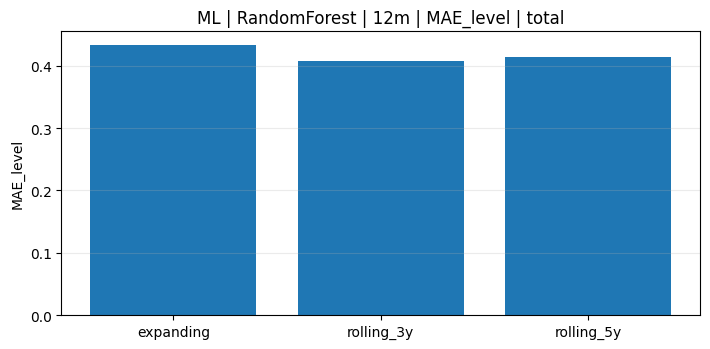

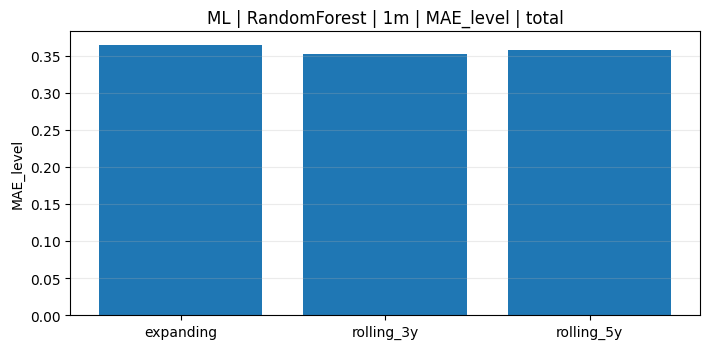

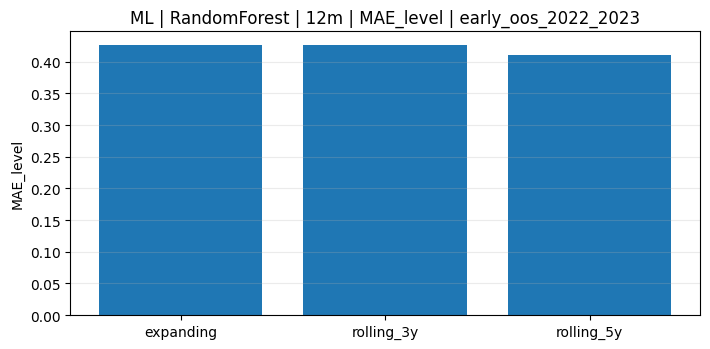

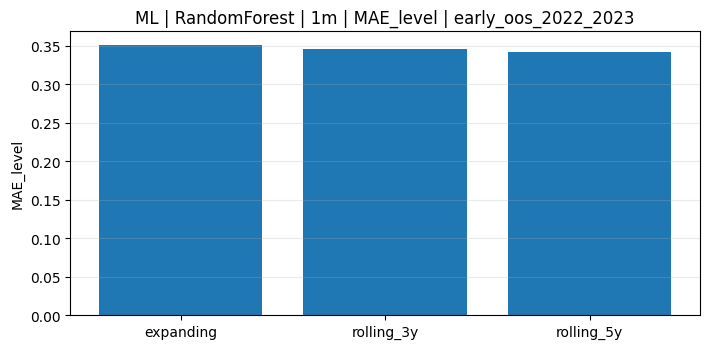

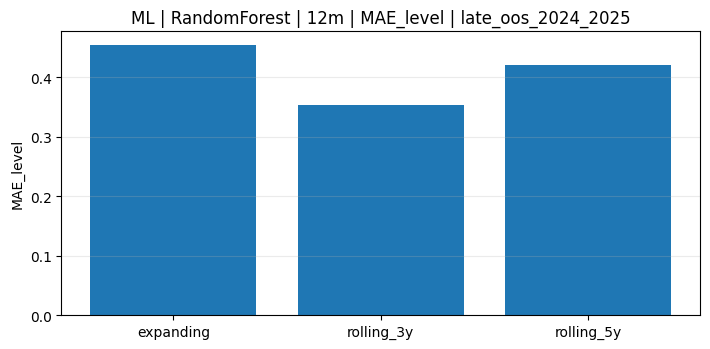

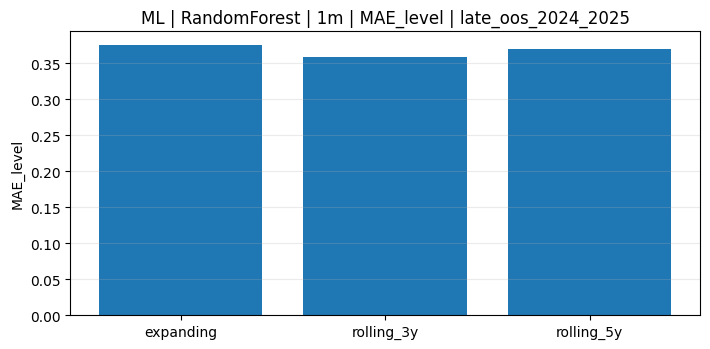

In [28]:

# =========================
# 11) Gráficos
# =========================

def plot_metric_bars(metrics_df: pd.DataFrame, metric: str, sample: str):
    sub = metrics_df.loc[metrics_df["sample"] == sample].copy()
    if len(sub) == 0:
        print(f"⚠️ No hay datos para sample={sample}")
        return

    for (family, model, h_tag), g in sub.groupby(["family", "model", "h_tag"]):
        g = g.sort_values("window_type")
        fig = plt.figure(figsize=(7.2, 3.6))
        plt.bar(g["window_type"], g[metric])
        plt.title(f"{family} | {model} | {h_tag} | {metric} | {sample}")
        plt.ylabel(metric)
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()

        fname = f"{family.lower()}_{h_tag}_{re.sub(r'[^A-Za-z0-9_]+','',str(model))}_{metric}_{sample}.png"
        out = PLOTS_DIR / fname
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()

for sample in ["total", "early_oos_2022_2023", "late_oos_2024_2025"]:
    plot_metric_bars(metrics_all, "MAE_level", sample)


## 12) Resumen ejecutivo automático

La tabla siguiente resume, para cada experimento, si las ventanas rolling mejoran o empeoran respecto del baseline `expanding`.


In [29]:

# =========================
# 12) Resumen ejecutivo
# =========================

def classify_change(delta, metric_type="error"):
    if pd.isna(delta):
        return "NA"
    if metric_type == "error":
        if delta < 0:
            return "Mejora rolling"
        if delta > 0:
            return "Empeora rolling"
        return "Igual"
    else:  # R2
        if delta > 0:
            return "Mejora rolling"
        if delta < 0:
            return "Empeora rolling"
        return "Igual"

exec_rows = []
for _, r in delta_total.iterrows():
    row = {
        "family": r["family"],
        "model": r["model"],
        "h_tag": r["h_tag"],
        "delta_MAE_rolling_3y": r.get("delta_MAE_level__rolling_3y_minus_expanding", np.nan),
        "delta_MAE_rolling_5y": r.get("delta_MAE_level__rolling_5y_minus_expanding", np.nan),
        "lectura_rolling_3y": classify_change(r.get("delta_MAE_level__rolling_3y_minus_expanding", np.nan), "error"),
        "lectura_rolling_5y": classify_change(r.get("delta_MAE_level__rolling_5y_minus_expanding", np.nan), "error"),
    }
    exec_rows.append(row)

executive_summary = pd.DataFrame(exec_rows).sort_values(["family", "h_tag"]).reset_index(drop=True)
display(executive_summary)

executive_summary.to_csv(TABLES_DIR / "executive_summary_MAE.csv", index=False)
print("✅ Executive summary guardado en:", TABLES_DIR / "executive_summary_MAE.csv")


,family,model,h_tag,delta_MAE_rolling_3y,delta_MAE_rolling_5y,lectura_rolling_3y,lectura_rolling_5y
0,ML,RandomForest,12m,-0.025455,-0.019901,Mejora rolling,Mejora rolling
1,ML,RandomForest,1m,-0.011836,-0.007211,Mejora rolling,Mejora rolling


✅ Executive summary guardado en: c:\Users\jbrio\OneDrive - Universidad de Montevideo\Tesis MCD\Flujo de trabajo modelado y predicciones\Flujo sin BEVSA\results_n09\tables\executive_summary_MAE.csv
